### **Supervised Machine Learning**


- Supervised Machine Learning is a type of machine learning that learns the relationship between input and output.

- In Supervised Machine Learning, the relationship between the input and labeled output is learnt through the process of training
- Two types of Supervised Machine Learning :
  -  Classification
  -  Regression

- **Classification** is a type of supervised machine learning where the model learns from the data to predict a discrete event or an outcome
    - Logistic Regression, Random Forest Classifier are some of the many machine learning algorithms for a classification problem

- **Regression** is a type of supervised machine learning where the model learns from the data to predict continuous values such as weight.
    - Linear Regression, Gradient Boosted Trees Regression are some of the many machine learning algorithms for a regression problem


*Reference:*


*Géron, Aurélien. "Hands-on machine learning with Scikit-Learn." Keras, and TensorFlow: Concepts, tools, and techniques to build intelligent systems 1 (2019).*


### **Problem statement**



- Pyspark is an interface for Apache Spark, providing a way to interactively look at the data in a distributed environment

- Supports features including Spark SQL, DataFrame, ML pipeline, etc.,

- The task is a regression problem - for predicting the stability of electric grid. (Specifically, the maximum real part of the characteristic equation).

- The dataset for this problem can be found at : https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data






### **Importing required libraries**



In [ ]:
  # Importing the os module
  import os

  # Setting up Spark environment variable  - Install OpenJDK environment to run spark
  !apt-get install openjdk-11-jdk-headless -qq > /dev/null

  # Download Apache Spark 3.5.0 with hadoop quietly
  !wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz

  # Extract the Spark package
  !tar xf spark-3.5.0-bin-hadoop3.tgz

  # Set JAVA_HOME environment path pointing to where OpenJDK is installed
  os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

  # Set SPARK_HOME environment path pointing to where Spark is installed
  os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"


In [ ]:
# list the contents of the current working directory

!ls

drive	     spark-3.5.0-bin-hadoop3	  spark-3.5.0-bin-hadoop3.tgz.1
sample_data  spark-3.5.0-bin-hadoop3.tgz  spark-3.5.0-bin-hadoop3.tgz.2


In [ ]:
#Installing findspark package, necessary to run Spark from Jupyter Notebook
!pip install findspark --quiet

# Importing findspark Library
import findspark

In [ ]:
# Initializing Pyspark - locates spark installation

findspark.init()

### **A higher level and a slightly more straight forward approach for Spark installation**


In [ ]:
# !pip install pyspark

### **Importing Dependencies**

In [ ]:
# Importing SparkSession from pyspark.sql to create Spark entry points

from pyspark.sql import SparkSession


In [ ]:
# Calling the builder method and getOrCreate to create or
# retrieve a Spark session
# Spark runs locally with available cores

spark = SparkSession.builder \
        .master("local[*]") \
        .appName("My Spark Application") \
        .getOrCreate()


In [ ]:
# Elements of the created SparkSession

spark

In [ ]:
# Importing required libraries from pyspark.sql for data manipulation and modeling

# Libraries for data manipulation
from pyspark.sql.functions import col, when
import pandas as pd

# library for advanced data visualization
import seaborn as sns

# Libaries for the Regression model
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import GBTRegressor

In [ ]:
# Installing pytictoc for monitoring time elapsed during code execution
!pip install pytictoc --quiet

In [ ]:
# Importing TicToc class from pytictoc for the timing functionality
from pytictoc import TicToc

### **Importing the dataset**

In [ ]:
# Dependencies to import required files from google drive to google - colab environment

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importing the dataset 'Electric_grid.csv' to a dataframe

df = spark.read.csv('/content/drive/MyDrive/Electric_grid.csv', header = True,inferSchema = "true")

### **Data Understanding**

In [ ]:
# dataset - shape

print("Shape of the dataset : ", (df.count(),len(df.columns)))

Shape of the dataset :  (10000, 13)


In [ ]:
  # Dataset Columns

  df.columns

['tau1',
 'tau2',
 'tau3',
 'tau4',
 'p1',
 'p2',
 'p3',
 'p4',
 'g1',
 'g2',
 'g3',
 'g4',
 'stab']

In [ ]:
# Display the first 10 rows of the DataFrame:

df.show(n = 10)

+-----------------+----------------+----------------+----------------+----------------+------------------+------------------+------------------+-----------------+------------------+-----------------+-----------------+-------------------+
|             tau1|            tau2|            tau3|            tau4|              p1|                p2|                p3|                p4|               g1|                g2|               g3|               g4|               stab|
+-----------------+----------------+----------------+----------------+----------------+------------------+------------------+------------------+-----------------+------------------+-----------------+-----------------+-------------------+
| 2.95906002455997|3.07988520422811|8.38102539191882|9.78075443222607|3.76308477206316|-0.782603630987543| -1.25739482958732|  -1.7230863114883|0.650456460887227| 0.859578105752345|0.887444920638513|0.958033987602737| 0.0553474891727752|
|  9.3040972346785|4.90252411201167|3.0475407276

### **Description of the dataset**

In [ ]:
# Generative basic Descriptive statistics for 'Electric_grid.csv' with df.describe() method

df.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+--------------------+
|summary|              tau1|              tau2|              tau3|              tau4|                p1|                 p2|                p3|                 p4|                 g1|                g2|                g3|                g4|                stab|
+-------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+-------------------+------------------+------------------+------------------+--------------------+
|  count|             10000|             10000|             10000|             10000|             10000|              10000|             10000|              10000|              10000|             10000|            

In [ ]:
# Generating Extended summary for some features

df.select(['tau1','tau2','tau3','tau4', 'stab']).summary().show()

+-------+------------------+------------------+------------------+------------------+--------------------+
|summary|              tau1|              tau2|              tau3|              tau4|                stab|
+-------+------------------+------------------+------------------+------------------+--------------------+
|  count|             10000|             10000|             10000|             10000|               10000|
|   mean| 5.249999930614209| 5.250001022042511|5.2500035241544225| 5.249997064361223|0.015730900002765957|
| stddev|2.7425483741341647|2.7425486737170175|2.7425494575854055|2.7425555299775657| 0.03691903236673799|
|    min| 0.500793021360319| 0.500141360493773| 0.500788152733829| 0.500472961226082| -0.0807598924160244|
|    25%|  2.87351900588397|  2.87329351296856|  2.87381617714777|  2.87365390665039|  -0.015577536320852|
|    50%|  5.24836386642556|  5.24870297523336|  5.24832774303022|  5.24834374722567|  0.0171375829096197|
|    75%|  7.62373306310291|  7.62330

In [ ]:
# Display the schema of the DataFrame, which shows it in a tree format

df.printSchema()

root
 |-- tau1: double (nullable = true)
 |-- tau2: double (nullable = true)
 |-- tau3: double (nullable = true)
 |-- tau4: double (nullable = true)
 |-- p1: double (nullable = true)
 |-- p2: double (nullable = true)
 |-- p3: double (nullable = true)
 |-- p4: double (nullable = true)
 |-- g1: double (nullable = true)
 |-- g2: double (nullable = true)
 |-- g3: double (nullable = true)
 |-- g4: double (nullable = true)
 |-- stab: double (nullable = true)



In [ ]:
# Display the datatypes of DataFrame Column datatypes with df.dytpes property which returns a list of tuples

df.dtypes

[('tau1', 'double'),
 ('tau2', 'double'),
 ('tau3', 'double'),
 ('tau4', 'double'),
 ('p1', 'double'),
 ('p2', 'double'),
 ('p3', 'double'),
 ('p4', 'double'),
 ('g1', 'double'),
 ('g2', 'double'),
 ('g3', 'double'),
 ('g4', 'double'),
 ('stab', 'double')]

In [ ]:
# Creating a new dataframe with the first 5 rows of the original dataframe df with df.limit() method

df1 = df.limit(5)
df1.show()

+-----------------+----------------+----------------+----------------+----------------+------------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+-------------------+
|             tau1|            tau2|            tau3|            tau4|              p1|                p2|               p3|                p4|               g1|               g2|               g3|               g4|               stab|
+-----------------+----------------+----------------+----------------+----------------+------------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+-------------------+
| 2.95906002455997|3.07988520422811|8.38102539191882|9.78075443222607|3.76308477206316|-0.782603630987543|-1.25739482958732|  -1.7230863114883|0.650456460887227|0.859578105752345|0.887444920638513|0.958033987602737| 0.0553474891727752|
|  9.3040972346785|4.90252411201167|3.04754072762177|1.3

In [ ]:
# Slicing a dataframe with df.collect() and indexing

# Collecting the rows to a list and slicing the list to create subsets of rows.

row_list = df.collect()
slice_1 = row_list[:5]  # First five rows
slice_2 = row_list[5:]  # Rows starting the sixth

# Creating dataframes from the sliced row lists

df_1 = spark.createDataFrame(slice_1)
df_2 = spark.createDataFrame(slice_2)

# Display the first part of the original dataframe
print("First part of the dataframe :")
df_1.show()


# Display the remaining part of the original dataframe
print("Remaining part of the dataframe :")
df_2.show()

#

First part of the dataframe :
+-----------------+----------------+----------------+----------------+----------------+------------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+-------------------+
|             tau1|            tau2|            tau3|            tau4|              p1|                p2|               p3|                p4|               g1|               g2|               g3|               g4|               stab|
+-----------------+----------------+----------------+----------------+----------------+------------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+-------------------+
| 2.95906002455997|3.07988520422811|8.38102539191882|9.78075443222607|3.76308477206316|-0.782603630987543|-1.25739482958732|  -1.7230863114883|0.650456460887227|0.859578105752345|0.887444920638513|0.958033987602737| 0.0553474891727752|
|  9.3040972346785|4.90252

### **Assess null values : Data Cleaning**

In [ ]:
# Loop through each column in the DataFrame
# Count and display the null values

for column in df.columns:
  nu_count = df.filter(col(column).isNull()).count()

  if nu_count > 0 :
    print(f"Column {column} has {nu_count} null values:")
    df.filter(col(column).isNull()).show()

  else:
    print(f"Column {column} has no null values")

Column tau1 has no null values
Column tau2 has no null values
Column tau3 has no null values
Column tau4 has no null values
Column p1 has no null values
Column p2 has no null values
Column p3 has no null values
Column p4 has no null values
Column g1 has no null values
Column g2 has no null values
Column g3 has no null values
Column g4 has no null values
Column stab has no null values


### **Converting to a Pandas DataFrame**

To facilitate visualization of the DataFrame with Seaborn, it is essential to convert the PySpark DataFrame to a Pandas DataFrame - since PySpark doesn't natively support Seaborn for visualizations



In [ ]:
# Conversion of the PySpark dataframe to a Pandas dataframe

df_pandas = df.toPandas()

In [ ]:
#Display the first five rows of the Pandas DataFrame
df_pandas.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860


<Axes: xlabel='tau1', ylabel='Count'>

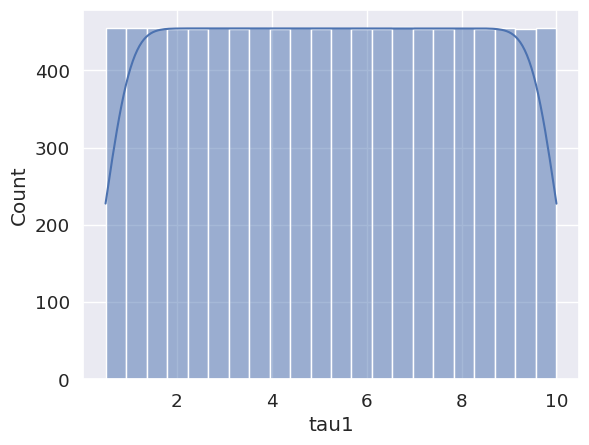

In [ ]:
# Histogram(Histplot) with Seaborn for the 'tau1' column, shows a uniform distribution
sns.set(font_scale= 1.2)
sns.histplot(data = df_pandas, x = "tau1", kde = True)


<Axes: ylabel='tau1'>

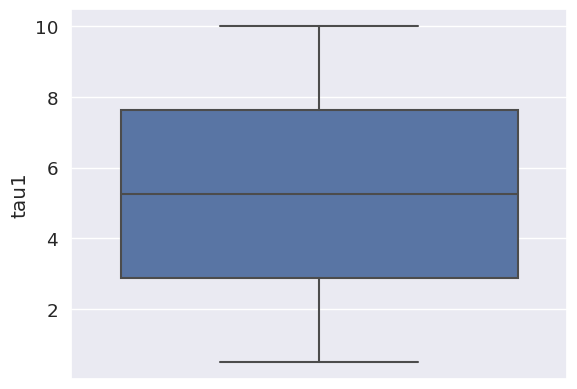

In [ ]:
# Distribution of the 'tau1' column in the form of a box plot
# The box plot shows no apparent outliers in the data beyond the whisker

sns.boxplot(data = df_pandas, y= "tau1")

<Axes: xlabel='p1', ylabel='Count'>

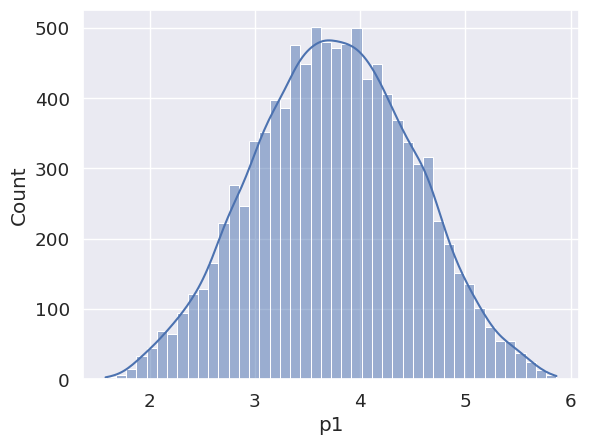

In [ ]:
# Histogram(Histplot) with Seaborn for the 'p1' column, shows a nearly symmetrical distribution and a kernel density estimate

sns.histplot(data = df_pandas, x = "p1", kde = True)

<Axes: ylabel='stab'>

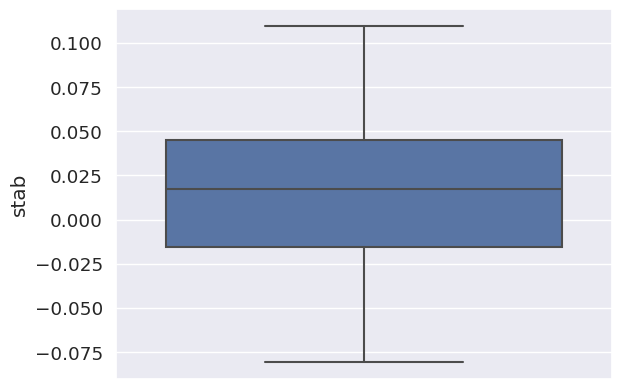

In [ ]:
# Distribution of "stab" in the form of a box plot, shows there are no apparent
# outliers in the data

sns.boxplot(data = df_pandas, y = "stab")

### **Correlation - Analysis**

- Useful for feature selection

In [ ]:
# df_pandas.corr() method to determine the correlation coefficient between columns

df_pandas.corr()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
tau1,1.000000,0.015586,-0.005970,-0.017265,0.027183,-0.015485,-0.015924,-0.015807,0.010521,0.015350,-0.001279,0.005494,0.275761
tau2,0.015586,1.000000,0.014273,-0.001965,-0.004769,0.006573,0.007673,-0.005963,-0.001742,0.015383,0.016508,-0.011764,0.290975
tau3,-0.005970,0.014273,1.000000,0.004354,0.016953,-0.003134,-0.008780,-0.017531,-0.011605,0.007671,0.014702,-0.011497,0.280700
tau4,-0.017265,-0.001965,0.004354,1.000000,-0.003173,0.010553,0.006169,-0.011211,-0.004149,0.008431,0.003260,-0.000491,0.278576
p1,0.027183,-0.004769,0.016953,-0.003173,1.000000,-0.573157,-0.584554,-0.579239,0.000721,0.015405,0.001069,-0.015451,0.010278
p2,-0.015485,0.006573,-0.003134,0.010553,-0.573157,1.000000,0.002388,-0.006844,0.015603,-0.018032,0.007555,0.019817,0.006255
p3,-0.015924,0.007673,-0.008780,0.006169,-0.584554,0.002388,1.000000,0.012953,-0.003219,-0.011575,-0.005897,-0.010485,-0.003321
p4,-0.015807,-0.005963,-0.017531,-0.011211,-0.579239,-0.006844,0.012953,1.000000,-0.013636,0.002850,-0.003515,0.017505,-0.020786
g1,0.010521,-0.001742,-0.011605,-0.004149,0.000721,0.015603,-0.003219,-0.013636,1.000000,0.007559,-0.005836,0.012431,0.282774
g2,0.015350,0.015383,0.007671,0.008431,0.015405,-0.018032,-0.011575,0.002850,0.007559,1.000000,-0.012809,-0.014909,0.293601


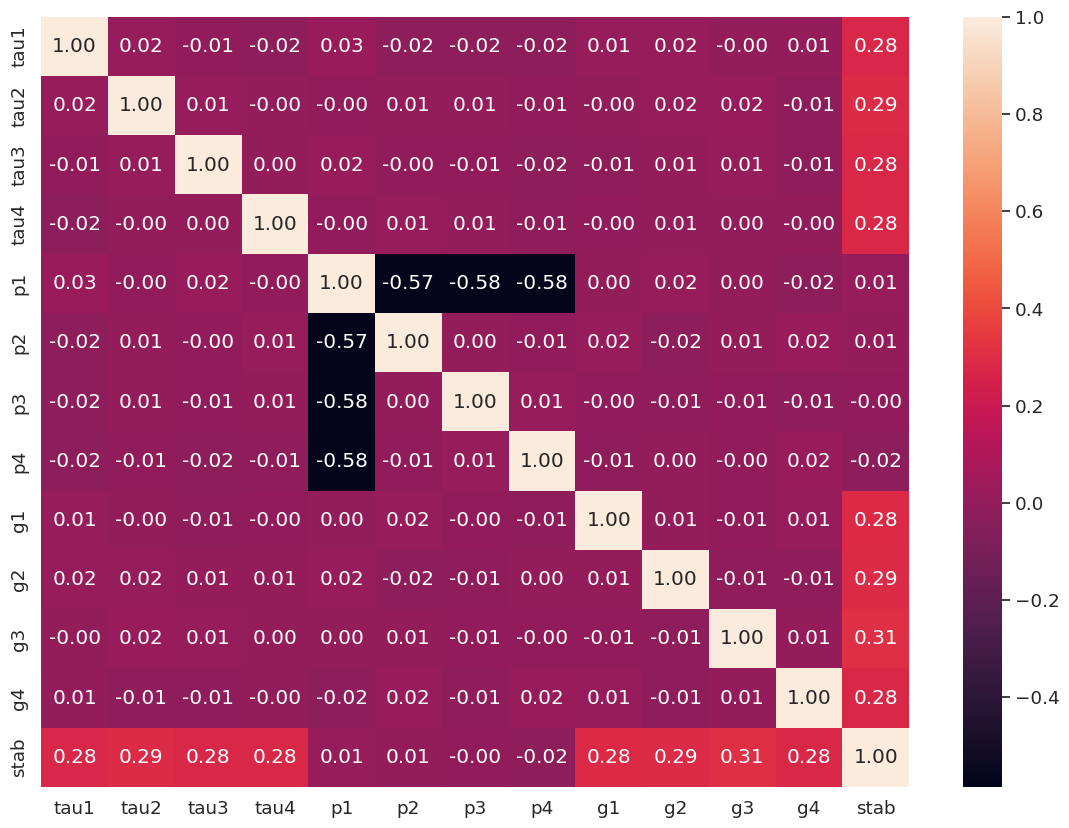

In [ ]:
# Representing the correlation coefficient between features in the form of a heatmap
# these coeffients provide a preliminary assessment of the extent to which
# there is correlation between the features and the sign of the relationship between
# features

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))
sns.heatmap(df_pandas.corr(), annot = True, fmt = "0.2f")
plt.show()

### **Vector Assembler to merge input features**

In [ ]:
# Importing Vector Assembler to merge input features into a vector- column for the model

from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=["tau1", "tau2", "tau3", "tau4", "p1", "p2", "p3", "p4", "g1", "g2", "g3", "g4"],outputCol = "features")

In [ ]:
# Applying the assembler.transform() method to create a dataframe with combined features in a vector-column
# Includes specified input columns and the output 'features' column

df_transformed = assembler.transform(df)

In [ ]:
df_transformed.show(5)

+-----------------+----------------+----------------+----------------+----------------+------------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+-------------------+--------------------+
|             tau1|            tau2|            tau3|            tau4|              p1|                p2|               p3|                p4|               g1|               g2|               g3|               g4|               stab|            features|
+-----------------+----------------+----------------+----------------+----------------+------------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+-------------------+--------------------+
| 2.95906002455997|3.07988520422811|8.38102539191882|9.78075443222607|3.76308477206316|-0.782603630987543|-1.25739482958732|  -1.7230863114883|0.650456460887227|0.859578105752345|0.887444920638513|0.958033987602737| 0.05534748917

In [ ]:
# Displaying the first five rows of the "features" column

df_transformed.select("features").show(truncate=False, n=5)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                                             |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[2.95906002455997,3.07988520422811,8.38102539191882,9.78075443222607,3.76308477206316,-0.782603630987543,-1.25739482958732,-1.7230863114883,0.650456460887227,0.859578105752345,0.887444920638513,0.958033987602737] |
|[9.3040972346785,4.90252411201167,3.04754072762177,1.36935735529605,5.06781210427845,-1.94005842705193,-1.87274168559721,-1.25501199162

### **Gradient Boosted Trees Regression Model**

- Gradient Boosting is a powerful machine learning technique that combines multiple weak learners (such as decision trees) to form a robust predictor

- The algorithm initially fits a simple model (such as a decision tree) to the data. The residual from this model is then used to train a second model, which is subsequently added to the ensemble.

- This process repeats several times with each subsequent model trained on the residual from the previous model

- The final predictor is the sum of all the models in the ensemble


In [ ]:
# Initializing GBTRegressor with the input features and the 'stab' output column, set maxIter specified to be 150

gbr = GBTRegressor(featuresCol="features", labelCol = "stab", maxIter = 150)

In [ ]:
# Setting the dataframe into a tuple of train and test datasets -  80% for training and 20% for test

(train, test) = df_transformed.randomSplit([0.8, 0.2])

In [ ]:
# Setting up the modeling pipeline in Pyspark for the GBT Regressor

pipeline = Pipeline(stages=[gbr])

pipeline

Pipeline_21ef6cc45310

In [ ]:
# Constructing the Parameter Grid to evaluate the maxDepth parameter for the gradient boosted tree regression model

paramGrid = ParamGridBuilder() \
            .addGrid(gbr.maxDepth, [3, 5, 6]) \
            .build()

In [ ]:
# Setting the Regression Evaluator to quantify the R2 score for the GBT Regressor Model

evaluator = RegressionEvaluator(metricName = "r2", labelCol = "stab", predictionCol = "prediction")

In [ ]:
# Setting up CrossValidator with the defined ParamGrid, evaluator and the model pipeline

Cross_validator = CrossValidator(estimator = pipeline, evaluator = evaluator, estimatorParamMaps = paramGrid, numFolds = 5)

In [ ]:
# Training the model with CrossValidator.fit() method
# timing functionality to quantify the time elapsed
t = TicToc()
t.tic()
model = Cross_validator.fit(train)
t.toc()

Elapsed time is 1212.001039 seconds.


In [ ]:
 # Making predictions on the training dataset with model.transform() method

response_1 = model.transform(train)

In [ ]:
# Calculation of R2 score for the training set

evaluator.evaluate(response_1)

0.9321357494403487

In [ ]:
# Making Predictions on the test dataset with the model.transform() method

response= model.transform(test)

In [ ]:
# Calculating the R2 score for the model

evaluator.evaluate(response)

0.9103164189035045

### **Feature Importance**

In [ ]:
# Retrieving the Best Model from the trained CrossValidator for feature importance analysis

gbt = model.bestModel

In [ ]:
# Retrieve the stages from the pipeline of the best model

gbt.stages

[GBTRegressionModel: uid=GBTRegressor_ef9564ec6582, numTrees=150, numFeatures=12]

In [ ]:
# Retrieving the feature importances for each of the 12 features for the gbt regressor model

feature_importances = model.bestModel.stages[0].featureImportances
feature_importances

SparseVector(12, {0: 0.0951, 1: 0.1365, 2: 0.1795, 3: 0.1159, 4: 0.0003, 5: 0.0006, 6: 0.0009, 7: 0.0004, 8: 0.0834, 9: 0.1289, 10: 0.1604, 11: 0.098})

In [ ]:
# Converting the feature importance to an Array for plotting / visualization
# Create a Pandas DataFrame  consisting of feature names and the corresponding feature importance values

feature_importances_ = feature_importances.toArray()
feature_names = ['tau1','tau2','tau3','tau4','p1','p2','p3','p4','g1','g2','g3','g4']


df_features = pd.DataFrame({'feature':feature_names, 'feature_importance': feature_importances_})
df_sorted = df_features.sort_values(by =['feature_importance'], ascending = False)

In [ ]:
# Plotting the feature importance for the 8 top features with plotly library

pd.options.plotting.backend = "plotly"

df_sorted[:8].plot.bar(x = "feature", y = "feature_importance")

- These feature importance values align well with the correlation analysis
- Incorporating a feature selection could further refine the model if needed.
- Since in this situation the quantified R2 score looks reasonable further refinement with
feature selection has not been included

### **Quiz**

Use Seaborn library to visualize the distribution of 'tau3' and 'g2' features in the form of a box plot

In [ ]:
# Importing Pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt


<Axes: ylabel='tau3'>

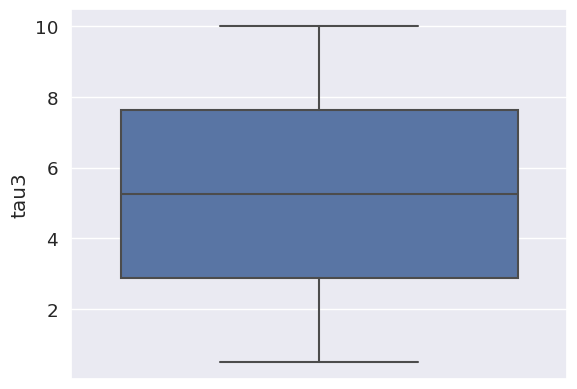

In [ ]:
sns.boxplot(data = df_pandas, y = "tau3")

<Axes: ylabel='g2'>

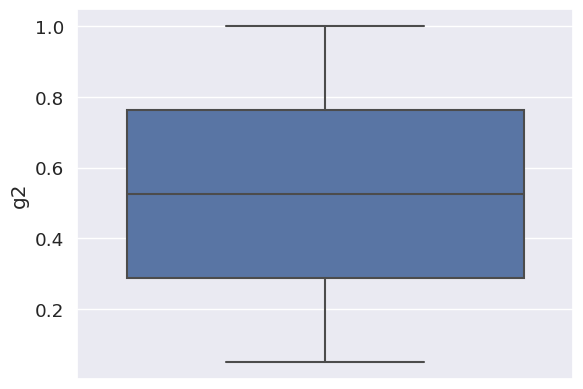

In [ ]:
sns.boxplot(data = df_pandas, y = "g2")

Conceptual Quiz :

Why gradient boosted tree regressors outperform individual decision trees?

- The merits of using gradient boosted tree regression model are due their ensemble nature, where each tree in the sequence, takes the prediction from the previous one and adjusts it closer to the true value.
- Furthermore, each successive tree corrects the errors from the previous one, gradually improving the model's performance